## Formation : Analyse de séries temporelles (TSA)

### 1) Objectif
L’objectif d’une analyse de séries temporelles est de comprendre comment une variable évolue dans le temps et d’identifier :
- la tendance,
- la saisonnalité,
- les variations aléatoires,
- les anomalies ou pics exceptionnels.

C’est une méthode fondamentale pour analyser les prix d’actions, les températures, les ventes, la consommation électrique, etc.

### 2) Expressions et mots-clés essentiels

- Trend = tendance
- Seasonality = saisonnalité
- Residual = résidu / bruit
- Moving average = moyenne mobile
- Rolling window = fenêtre glissante
- Decomposition = décomposition
- Stationarity = stationnarité
- Forecast = prévision
- Time index = index temporel
- Period = période (ex. 12 mois, 7 jours)

### 3) Formule de base
Une série peut souvent s’écrire comme :

Y(t) = T(t) + S(t) + R(t)

- Y(t) : valeur observée
- T(t) : tendance
- S(t) : saisonnalité
- R(t) : résidu

### 4) Exemple concret
- Les ventes d’un magasin peuvent augmenter pendant les fêtes.
- Les températures montent en été et baissent en hiver.
- Les cours boursiers ont souvent une tendance générale plus difficile à lire à cause de la volatilité.

### 5) Ce qu’on cherche à observer
- La série monte-t-elle globalement ?
- Y a-t-il un cycle régulier ?
- Les variations sont-elles brusques ou lissées ?
- Peut-on expliquer une partie par la saisonnalité ?

### 6) Outils utilisés
- pandas : gestion des dates et des données
- matplotlib : visualisation
- statsmodels : décomposition et analyse statistique

---

### Exemple visuel : interprétation des composantes

Une série temporelle typique contient souvent :
1. une tendance générale,
2. une variation périodique,
3. un bruit aléatoire.

La moyenne mobile permet de lisser la courbe pour mieux voir la tendance.
La décomposition permet d’isoler la tendance, la saisonnalité et le résidu.

---

### Mots-clés utiles pour la présentation

- Analyse de séries temporelles
- Signal temporel
- Pattern
- Smoothing
- Lissage
- Forecasting
- Seasonal effect
- Trend detection
- Anomaly detection
- Data frequency

---

### Exemple de phrase à utiliser dans le rapport

> La série temporelle présente une tendance ascendante sur la période étudiée, avec une composante saisonnière claire et des fluctuations résiduelles faibles. La moyenne mobile confirme l’orientation générale de la série.

---

### Bonnes habitudes
- toujours convertir la colonne date en index temporel,
- vérifier les valeurs manquantes,
- identifier la fréquence des données,
- utiliser la moyenne mobile pour voir la tendance,
- décomposer la série avant de conclure.


/tmp/ipykernel_16019/2346640453.py:32: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  result = seasonal_decompose(series, model='additive', period=12, extrapolate_trend='freq')


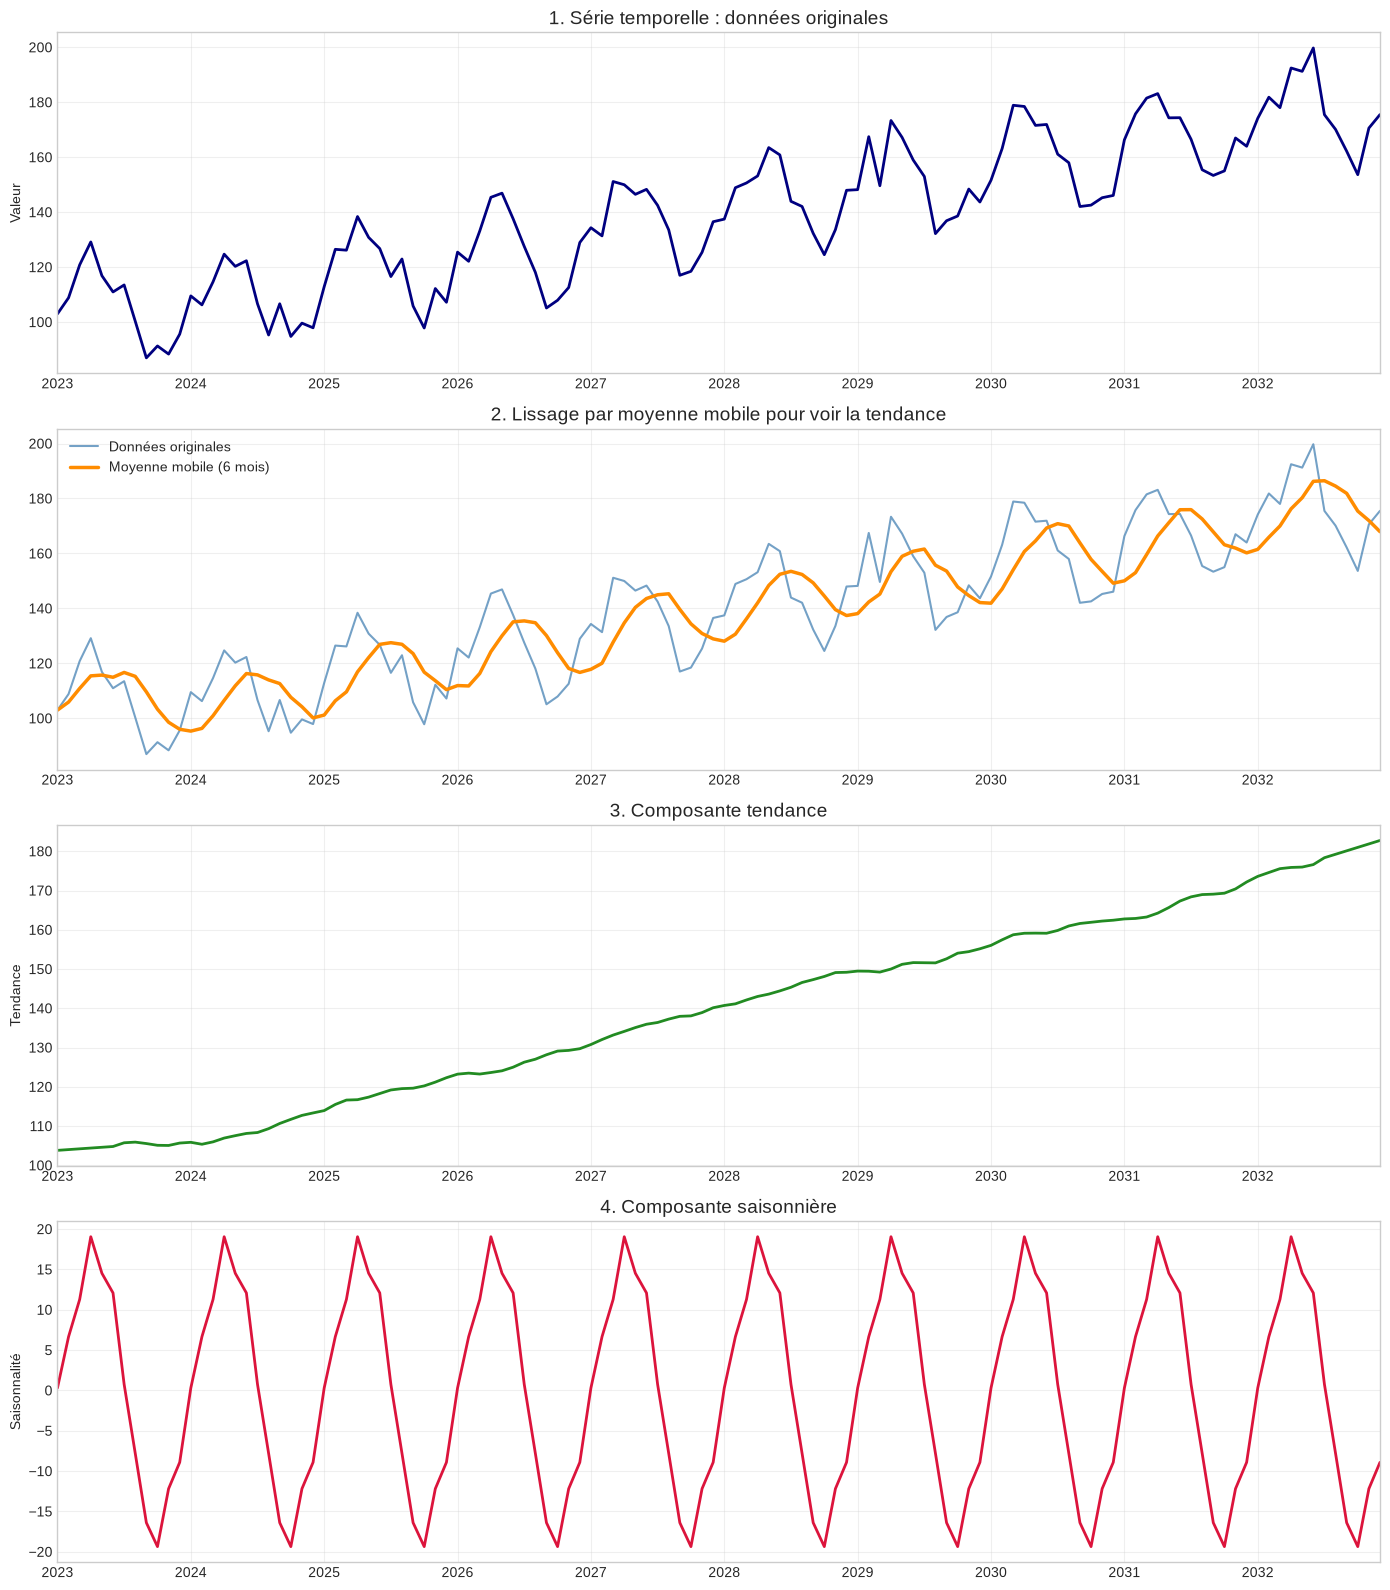


Interprétation rapide :
- La tendance montre la direction générale de la série.
- La saisonnalité montre les variations périodiques.
- La moyenne mobile aide à lisser le bruit et à mieux voir la tendance.
- Le résidu représente ce qui reste après extraction de la tendance et de la saisonnalité.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Exemple synthétique de données temporelles
idx = pd.date_range('2023-01-01', periods=120, freq='ME')
trend = np.linspace(100, 180, len(idx))
seasonality = 18 * np.sin(np.arange(len(idx)) * 2 * np.pi / 12)
noise = np.random.normal(0, 6, len(idx))
series = pd.Series(trend + seasonality + noise, index=idx, name='Valeur')

# 1) Série temporelle originale
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
series.plot(ax=axes[0], color='navy', linewidth=2)
axes[0].set_title('1. Série temporelle : données originales', fontsize=14)
axes[0].set_ylabel('Valeur')
axes[0].grid(True, alpha=0.3)

# 2) Moyenne mobile
moving_avg = series.rolling(window=6, min_periods=1).mean()
series.plot(ax=axes[1], color='steelblue', alpha=0.75, label='Données originales')
moving_avg.plot(ax=axes[1], color='darkorange', linewidth=2.5, label='Moyenne mobile (6 mois)')
axes[1].set_title('2. Lissage par moyenne mobile pour voir la tendance', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) Décomposition de la série
result = seasonal_decompose(series, model='additive', period=12, extrapolate_trend='freq')
result.trend.plot(ax=axes[2], color='forestgreen', linewidth=2)
axes[2].set_title('3. Composante tendance', fontsize=14)
axes[2].set_ylabel('Tendance')
axes[2].grid(True, alpha=0.3)

result.seasonal.plot(ax=axes[3], color='crimson', linewidth=2)
axes[3].set_title('4. Composante saisonnière', fontsize=14)
axes[3].set_ylabel('Saisonnalité')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5) Résumé textuel
print('\nInterprétation rapide :')
print('- La tendance montre la direction générale de la série.')
print('- La saisonnalité montre les variations périodiques.')
print('- La moyenne mobile aide à lisser le bruit et à mieux voir la tendance.')
print('- Le résidu représente ce qui reste après extraction de la tendance et de la saisonnalité.')
